# 🟩 확률 분포에서 손실 함수까지

## 🟢 1. 밀도와 확률의 차이

PDF = Probability Density Function(확률 밀도 함수). 연속 변수에서 한 점의 확률은 0이고 구간 아래 면적이 확률이다. PDF 값은 1보다 클 수도 있다.

PMF = Probability Mass Function(확률 질량 함수). 이산 결과 하나하나에 확률을 부여한다. 모든 결과의 확률을 더하면 1이다.

정규분포는 $N(\mu,\sigma^2)$ 표기를 사용한다. 따라서 `N(2,0.5)`의 분산은 `0.5`, 표준편차는 $\sqrt{0.5}$다.

$$p(x)=\frac{1}{\sqrt{2\pi\sigma^2}}\exp\left(-\frac{(x-\mu)^2}{2\sigma^2}\right)$$

베르누이 분포는 성공 확률 p로 결과 0과 1을 모델링한다.

$$P(Y=y)=p^y(1-p)^{1-y},\quad y\in\{0,1\}$$

In [1]:
from pathlib import Path  # 프로젝트 폴더를 찾는다.
import sys  # 모듈 검색 위치를 설정한다.
import numpy as np  # 수학 계산을 직접 수행한다.
ROOT = Path.cwd() if (Path.cwd() / "src").is_dir() else Path.cwd().parent  # 루트 또는 notebooks 폴더에서 실행한다.
assert (ROOT / "src").is_dir(), "Run from project root or notebooks folder."  # 실행 위치를 검사한다.
sys.path.insert(0, str(ROOT))  # 프로젝트 모듈을 불러올 수 있게 한다.
np.random.seed(42)  # 같은 난수로 재현한다.
np.set_printoptions(precision=10, suppress=True)  # 중간값을 충분한 자리수로 보여준다.

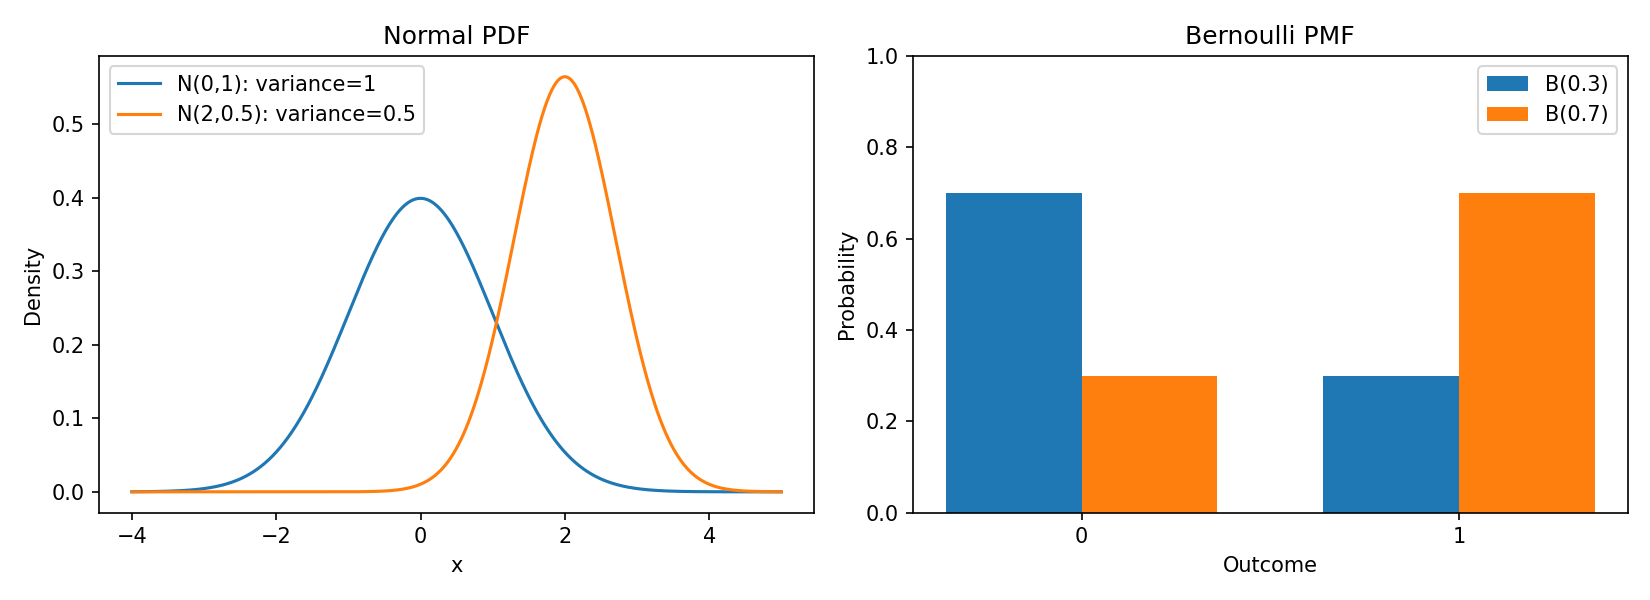

mean, variance, integral: 0 1 1.0
mean, variance, integral: 2 0.5 1.0000000000000002
Bernoulli 0.3 [0.7 0.3]
Bernoulli 0.7 [0.3 0.7]


In [2]:
import matplotlib  # 화면 없이 그림을 저장하는 도구를 가져온다.
matplotlib.use("Agg")  # PNG 파일로 출력한다.
from IPython.display import Image, display  # 노트북 안에 저장한 그림을 표시한다.
from src.visualization import plot_distributions  # 두 PDF와 두 PMF를 그리는 함수를 가져온다.
from src.probability import bernoulli_pmf, cross_entropy, entropy, kl_divergence, normal_pdf, softmax  # 직접 만든 확률 함수를 가져온다.
plot_distributions(ROOT / "outputs" / "probability_distributions.png")  # 요구사항의 분포 그림을 저장한다.
display(Image(filename=str(ROOT / "outputs" / "probability_distributions.png")))  # 결과 그림을 노트북에 포함한다.
x_grid = np.linspace(-10, 10, 20001)  # PDF 검사용 넓은 구간을 만든다.
for mean, variance in [(0, 1), (2, 0.5)]:  # 두 정규분포를 확인한다.
    integral = np.trapezoid(normal_pdf(x_grid, mean, variance), x_grid)  # PDF 아래의 면적을 계산한다.
    print("mean, variance, integral:", mean, variance, integral)  # 실제 계산 결과를 기록한다.
    assert abs(integral - 1) < 1e-6  # 면적이 1인지 확인한다.
for p in [0.3, 0.7]:  # 두 베르누이 분포를 확인한다.
    print("Bernoulli", p, bernoulli_pmf(p))  # 실패와 성공의 확률을 보여준다.
    assert abs(bernoulli_pmf(p).sum() - 1) < 1e-12  # 확률의 합을 확인한다.

## 🟢 2. MSE와 정규분포의 MLE

MSE = Mean Squared Error(평균 제곱 오차). MLE = Maximum Likelihood Estimation(최대우도추정).

우도는 관찰한 데이터를 고정하고 모델 매개변수를 바꾸며 계산한 값이다. 매개변수 자체의 확률 분포는 아니다.

독립적인 관측, 조건부 정규 오차, 모든 관측에 같은 고정 양수 분산을 가정한다.

$$y_i=f_\theta(x_i)+\epsilon_i,\quad \epsilon_i\sim N(0,\sigma^2)$$

$$p(y_i\mid x_i,\theta)=\frac{1}{\sqrt{2\pi\sigma^2}}\exp\left[-\frac{(y_i-f_\theta(x_i))^2}{2\sigma^2}\right]$$

1. 독립이면 전체 우도는 개별 확률 밀도의 곱이다.
2. 로그는 증가 함수이므로 최댓값의 위치를 바꾸지 않는다.
3. 곱의 로그는 합이 된다.
4. 최대화 대신 음수를 붙여 최소화한다.

$$\operatorname*{argmax}_\theta\prod_i p(y_i\mid x_i,\theta)=\operatorname*{argmin}_\theta\left[\frac{n}{2}\log(2\pi\sigma^2)+\frac{1}{2\sigma^2}\sum_i(y_i-f_\theta(x_i))^2\right]$$

첫 항은 theta와 무관하다. 둘째 항의 양수 배율을 제거해도 최적 매개변수는 같다.

$$\operatorname*{argmin}_\theta\sum_i(y_i-f_\theta(x_i))^2=\operatorname*{argmin}_\theta\frac{1}{n}\sum_i(y_i-f_\theta(x_i))^2=\operatorname*{argmin}_\theta MSE$$

동일한 최적점을 갖는다는 의미다. 두 목적 함수의 수치나 기울기 크기가 같다는 뜻은 아니다. 관측별 분산이 다르면 가중 제곱 오차가 나온다.

In [3]:
observed = np.array([1.0, 2.0, 3.0])  # 작은 관찰 데이터를 만든다.
mu_grid = np.linspace(0, 4, 81)  # 상수 예측 모델의 후보를 만든다.
variance = 0.5  # 오차 분산을 고정한다.
mse = np.array([np.mean((observed - mu) ** 2) for mu in mu_grid])  # 각 모델의 MSE를 계산한다.
nll = np.array([len(observed) * np.log(2 * np.pi * variance) / 2 + np.sum((observed - mu) ** 2) / (2 * variance) for mu in mu_grid])  # Gaussian 음의 로그 우도를 계산한다.
assert np.argmin(mse) == np.argmin(nll)  # 같은 최적점을 갖는지 확인한다.
print("MSE optimum:", mu_grid[np.argmin(mse)], "Gaussian MLE optimum:", mu_grid[np.argmin(nll)])  # 실제 일치 결과를 보여준다.

MSE optimum: 2.0 Gaussian MLE optimum: 2.0


## 🟢 3. Bernoulli와 Binary Cross-Entropy의 MLE

독립적인 이진 정답 $y_i\in\{0,1\}$과 모델이 예측한 성공 확률 $p_i$를 가정한다.

$$\mathcal L(\theta)=\prod_i p_i^{y_i}(1-p_i)^{1-y_i}$$

$$-\log\mathcal L(\theta)=-\sum_i\left[y_i\log p_i+(1-y_i)\log(1-p_i)\right]=\sum_i BCE_i$$

평균 BCE는 위 값을 n으로 나눈 것이다. 양수 상수로 나누어도 최적점은 같다. 따라서 BCE 최소화는 Bernoulli 모델에서의 MLE다.

## 🟢 4. Categorical과 Cross-Entropy의 MLE

Categorical(범주형) 분포는 여러 범주 중 하나의 결과를 표현한다. one-hot 정답은 정답 범주만 1이고 나머지는 0이다.

$$p_{i,c}=\operatorname{softmax}(z_i)_c=\frac{e^{z_{i,c}}}{\sum_j e^{z_{i,j}}}$$

$$P(y_i\mid x_i,\theta)=\prod_c p_{i,c}^{y_{i,c}}$$

$$-\log\mathcal L(\theta)=-\sum_i\sum_c y_{i,c}\log p_{i,c}=\sum_i CE_i$$

따라서 평균 다중 분류 Cross-Entropy(교차 엔트로피) 최소화는 Categorical 모델의 MLE다.

### 🟡 안전한 Softmax

$e^{1000}$을 바로 계산하면 수 표현 범위를 넘는다. $m=\max z$를 빼면 결과를 바꾸지 않고 안전하게 계산한다.

$$\frac{e^{z_c-m}}{\sum_j e^{z_j-m}}=\frac{e^{z_c}}{\sum_j e^{z_j}}$$

In [4]:
logits = np.array([1000.0, 1001.0, 1002.0])  # 오버플로가 생기기 쉬운 큰 점수를 만든다.
probabilities = softmax(logits)  # 최댓값을 뺀 안정적인 Softmax를 계산한다.
print("Softmax:", probabilities, "sum:", probabilities.sum())  # 확률과 합을 보여준다.
assert abs(probabilities.sum() - 1) <= 1e-6  # 요구사항의 합 오차를 검사한다.
np.testing.assert_allclose(probabilities, softmax(logits - 1000))  # 공통 상수를 빼도 같은지 확인한다.
target = np.array([0.0, 0.0, 1.0])  # 세 번째 범주를 정답으로 둔다.
categorical_ce = cross_entropy(target, probabilities)  # one-hot 교차 엔트로피를 구한다.
np.testing.assert_allclose(categorical_ce, -np.log(probabilities[2]))  # 정답 확률의 음의 로그와 비교한다.
y = np.array([0, 1, 1])  # 작은 Bernoulli 관찰 데이터를 만든다.
p_grid = np.linspace(0.01, 0.99, 99)  # 가능한 성공 확률 모델을 만든다.
bce = np.array([-np.mean(y * np.log(p) + (1 - y) * np.log(1 - p)) for p in p_grid])  # 평균 BCE를 계산한다.
likelihood = np.array([np.prod(p ** y * (1 - p) ** (1 - y)) for p in p_grid])  # 직접 우도의 곱을 계산한다.
assert np.argmin(bce) == np.argmax(likelihood)  # BCE 최소점과 우도 최대점을 비교한다.
print("Bernoulli BCE/MLE grid optimum:", p_grid[np.argmin(bce)], "sample mean:", y.mean())  # 격자 최적점과 이론상 최적점을 비교한다.

Softmax: [0.0900305732 0.2447284711 0.6652409558] sum: 0.9999999999999999
Bernoulli BCE/MLE grid optimum: 0.67 sample mean: 0.6666666666666666


## 🟢 5. 보너스: 엔트로피와 KL

$$H(p)=-\sum_i p_i\log p_i$$

$$H(p,q)=-\sum_i p_i\log q_i$$

$$D_{KL}(p\Vert q)=\sum_i p_i\log\frac{p_i}{q_i}=H(p,q)-H(p)$$

KL = Kullback–Leibler divergence(쿨백–라이블러 발산). KL은 방향에 따라 값이 달라져서 일반적인 거리가 아니다. 자연로그이면 단위는 nat이며 log base 2를 쓰면 bit다.

$0\log0=0$으로 정의한다. 실제 확률이 양수인데 예측 확률이 0이면 교차 엔트로피와 KL은 무한대다.

모델과 무관하게 p가 고정되면 H(p)도 고정된다. 따라서 교차 엔트로피를 줄이는 것은 실제 분포와 예측 분포 사이의 KL을 줄이는 것과 같은 최적점을 갖는다.

In [5]:
p, q = np.array([0.3, 0.7]), np.array([0.6, 0.4])  # 두 확률 분포를 만든다.
h, ce, kl = entropy(p), cross_entropy(p, q), kl_divergence(p, q)  # 세 정보량을 계산한다.
print("H(p):", h, "H(p,q):", ce, "KL(p||q):", kl)  # 실제 값을 기록한다.
np.testing.assert_allclose(ce, h + kl, atol=1e-12)  # 교차 엔트로피 분해를 확인한다.
assert kl >= 0  # KL이 음수가 아닌지 확인한다.
assert entropy([1, 0]) == 0  # 확실한 결과의 불확실성을 확인한다.
assert np.isinf(cross_entropy([1, 0], [0, 1]))  # 가능한 사건을 확률 0으로 예측했을 때를 확인한다.

H(p): 0.6108643020548935 H(p,q): 0.7946511994417057 KL(p||q): 0.1837868973868122


## 🟢 6. 더 공부할 내용과 출처

- 독립 관측 가정이 깨지면 단순한 우도의 곱으로 모델링할 수 없다.
- 평균 손실과 합계 손실은 최적점이 같아도 기울기 크기가 달라 학습률에 영향을 준다.
- MLE는 데이터에만 맞춘다. MAP = Maximum A Posteriori(최대 사후 확률 추정)는 매개변수의 사전 분포도 사용한다. Gaussian 사전 분포를 쓰면 L2 정규화 항이 나온다.
- L2는 가중치 제곱의 합이며, 학습 데이터에 지나치게 맞추는 과적합을 줄이는 방법 중 하나다.
- 훈련 데이터의 손실 감소만으로 새 데이터에 대한 성능을 보장할 수 없다. 훈련·검증·테스트 데이터를 구분해야 한다.

[Stanford CS229 확률·최대우도 강의 노트](https://cs229.stanford.edu/main_notes.pdf)

설명 연습: “MSE와 분류 교차 엔트로피는 각각 데이터의 오차를 정규분포, 정답을 Bernoulli 또는 Categorical 분포로 가정했을 때 나오는 음의 로그 우도다.”